## Convex and Nonconvex Optimization

#### by Qi Pan(Sophie Pan)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize

#### Setup the function and solve it by scipy.optimize.minimize

When using this solver to sove this problem, we can either setup the method or leave it blank. I have tried both leaving it blank and using method='Nelder-Mead'. The optimal value is nearly the same (difference starts from $10^{-8}$)

In [2]:
def f(x):
    return (1-x[0]+x[0]*x[1])**2+(2-x[0]+(x[0]**2)*x[1])**2+(3-x[0]+(x[0]**3)*x[1])**2

In [3]:
# Don't specify the method and give a try.
x_min = optimize.minimize(f, x0=[0, 0],bounds=((-5,5),(-5,5)))
print(x_min)
print(x_min.fun)

      fun: 1.168412307191077
 hess_inv: <2x2 LbfgsInvHessProduct with dtype=float64>
      jac: array([-2.39808173e-06,  2.90878432e-06])
  message: b'CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL'
     nfev: 48
      nit: 12
   status: 0
  success: True
        x: array([ 1.51907761, -0.27672453])
1.168412307191077


In [21]:
# Use method=Nelder-Mead 
x_min_Nelder_Mead = optimize.minimize(f, x0=[0, 0],method='Nelder-Mead',bounds=((-5,5),(-5,5)))
print(x_min_Nelder_Mead)
print(x_min_Nelder_Mead.fun)

 final_simplex: (array([[ 1.51904735, -0.27673147],
       [ 1.51911816, -0.27667892],
       [ 1.51906527, -0.27677334]]), array([1.16841231, 1.16841232, 1.16841234]))
           fun: 1.168412313483284
       message: 'Optimization terminated successfully.'
          nfev: 156
           nit: 82
        status: 0
       success: True
             x: array([ 1.51904735, -0.27673147])
1.168412313483284


#### Plot the 2D contour plot for f(x):

In [5]:
x = np.arange(-5, 5, 0.1)
y = np.arange(-5, 5, 0.1)
xg, yg = np.meshgrid(x, y) # grid of points

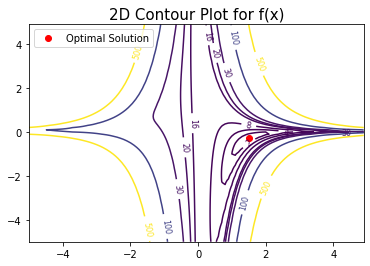

In [6]:
fig,ax=plt.subplots()
ax.set_title('2D Contour Plot for f(x)',fontsize=15)
contour=ax.contour(xg,yg,f([xg,yg]),levels=[1,2,4,8,16,20,30,100,500]) # draw the contour line
ax.clabel(contour,inline=True, fontsize=8) # draw contour line height lable
ax.plot(x_min.x[0],x_min.x[1],'or',label='Optimal Solution') # draw the optimization solution 
ax.legend(loc='upper left')

#### Plot the 3D surface for f(x)

I have use several methods to do the plot and they look a bit different. I was shocked at the beginning as the first 3D plot looks like a bow and the 2nd one looks more organic around the optimization point.

The reason for this difference is:

Function values at the corners is much higher then everywhere else (that is what we can see in the 1st picture). That majority of blue that you can see there is not flat, but looks like that due to all of those values being significantly smaller then the corner values. In the 2nd picture, we can actually see better what is going on in that blue area.

#### Method 1.

In [7]:
from mpl_toolkits.mplot3d import Axes3D

Text(0.5, 0.92, '3D Plot for f(x)')

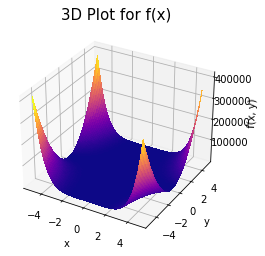

In [8]:
fig = plt.figure()
ax = plt.axes(projection='3d')
surf = ax.plot_surface(xg, yg, f([xg, yg]), rstride=1, cstride=1,
                       cmap=plt.cm.plasma, linewidth=0, antialiased=False)

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('f(x, y)')
ax.set_title('3D Plot for f(x)',fontsize=15)

#### Method 2.
I like *ax.contour3D( )* function since it allows me to set the range of the z axis. Thus we can see the details around the min point.

Text(0.5, 0.92, '3D Plot for f(x)')

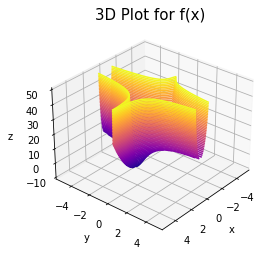

In [9]:
fig = plt.figure()
ax = plt.axes(projection='3d')
#choose plasma as the gradient color and set only 50 contour levels height
ax.contour3D(xg, yg, f([xg, yg]),50,cmap=plt.cm.plasma,levels=range(1,50)) 
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_zlim3d(-10,50) # set the z axis border 
ax.view_init(30, 40) # rotate the view point
ax.set_title('3D Plot for f(x)',fontsize=15)

## Coding for Another Nonconvex Function

In [10]:
def g(x):
    return -0.0001*(abs(np.sin(x[0])*np.sin(x[1])*np.exp(abs(100-(x[0]**2+x[1]**2)**0.5/np.pi)))+1)**0.1

This function is very complicated and we don't know where should be the starting point. Let's plot the 2D and 3D first to take a look and then decide.

#### Plot the 3D surface for g(x)

In [11]:
x = np.arange(-10, 10, 0.1)
y = np.arange(-10, 10, 0.1)
xg, yg = np.meshgrid(x, y) # grid of points

Text(0.5, 0.92, '3D Plot for g(x)')

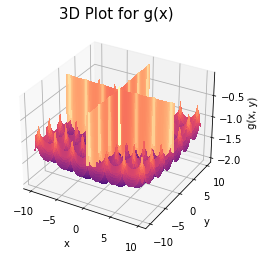

In [12]:
fig = plt.figure()
ax = plt.axes(projection='3d')
surf = ax.plot_surface(xg, yg, g([xg, yg]), rstride=1, cstride=1,
                       cmap=plt.cm.magma, linewidth=0, antialiased=False)

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('g(x, y)')
ax.set_title('3D Plot for g(x)',fontsize=15)

#### Plot the 2D contour plot for g(x):

<a list of 84 text.Text objects>

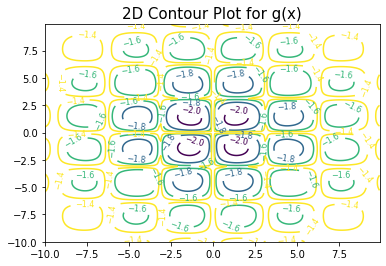

In [13]:
fig,ax=plt.subplots()
ax.set_title('2D Contour Plot for g(x)',fontsize=15)
contour=ax.contour(xg,yg,g([xg,yg]),levels=[-2,-1.8,-1.6,-1.4]) # draw the contour line
ax.clabel(contour,inline=True, fontsize=8) # draw contour line height lable

Based on the observation of the plots, the centered 4 areas with height level = -2.0 seems are locations for the global minima points. Let's try to use *Scipy.optimize.minizie()* to find these 4 minima points and compare.

Try start with (1,1)

In [14]:
res1 = optimize.minimize(g, x0=[1, 1],bounds=((-10,10),(-10,10)))
print(res1.x)
print(res1.fun)

[1.34938657 1.34938657]
-2.0626118707356023


Try start with (-1,-1)

In [15]:
res2 = optimize.minimize(g, x0=[-1, -1],bounds=((-10,10),(-10,10)))
print(res2.x)
print(res2.fun)

[-1.3493867 -1.3493867]
-2.0626118707367493


Try start with (-1,1)

In [16]:
res3 = optimize.minimize(g, x0=[-1, 1],bounds=((-10,10),(-10,10)))
print(res3.x)
print(res3.fun)

[-1.34938492  1.34938679]
-2.062611870729094


Try start with (1,-1)

In [17]:
res4 = optimize.minimize(g, x0=[1, -1],bounds=((-10,10),(-10,10)))
print(res4.x)
print(res4.fun)

[ 1.34938679 -1.34938492]
-2.062611870729094


Let's try to find some local minima points.

Try start with (5,4.8)

In [18]:
res_local1 = optimize.minimize(g, x0=[5,4.8],bounds=((-10,10),(-10,10)))
print(res_local1.x)
print(res_local1.fun)

[4.49100367 4.4910037 ]
-1.7906017238067369


Try start with (1,7.5)

In [19]:
res_local2 = optimize.minimize(g, x0=[1,7.5],bounds=((-10,10),(-10,10)))
print(res_local2.x)
print(res_local2.fun)

[1.50849688 7.55141118]
-1.7154894159888365


Let's plot all these points into our 2D contour plot. 

Make the global minima with red color and local minima with blue color.

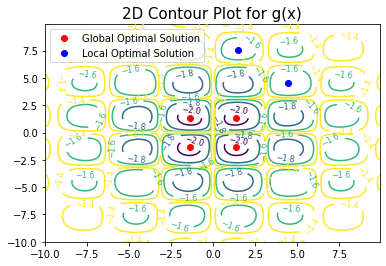

In [20]:
fig,ax=plt.subplots()
ax.set_title('2D Contour Plot for g(x)',fontsize=15)
contour=ax.contour(xg,yg,g([xg,yg]),levels=[-2,-1.8,-1.6,-1.4]) # draw the contour line
ax.clabel(contour,inline=True, fontsize=8) # draw contour line height lable

ax.plot(res1.x[0],res1.x[1],'or',label='Global Optimal Solution') 
ax.plot(res2.x[0],res2.x[1],'or')
ax.plot(res3.x[0],res3.x[1],'or')
ax.plot(res4.x[0],res4.x[1],'or')

ax.plot(res_local1.x[0],res_local1.x[1],'ob',label='Local Optimal Solution')
ax.plot(res_local2.x[0],res_local2.x[1],'ob')

ax.legend(loc='upper left')